In [24]:
import pandas as  pd
import os,sys

sys.path.append(os.path.abspath('..'))

from src.utils.l_file_data_loader import  download_data_files


# L0 dataloader

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from importlib import reload
import src.utils.L0_dataloaders as dl0

In [27]:

url='https://data.pandonia-global-network.org/Rome-SAP/Pandora117s1/L0/'
link = "Pandora117s1_Rome-SAP_20221001_L0.txt.bz2"

file_url = url + link

columns_to_read = ['time', 'routine_code', 'integration_time', 'detector_temp']


L0data_df, skipped_df = dl0.read_L0file(file_url, columns_to_read)

L0data_df.head()

Reading file from https://data.pandonia-global-network.org/Rome-SAP/Pandora117s1/L0/Pandora117s1_Rome-SAP_20221001_L0.txt.bz2


/Users/berni/PycharmProjects/OneSun/src/utils/L0_dataloaders.py:157: UserWarning: Unknown column name: detector_temp
  warnings.warn(f"Unknown column name: {short_name}")


,routine_code,integration_time,data
time,,,
2022-10-01 04:36:36.300,ZO,4000.0,"[11211.5, 10569.5, 10133.25, 9445.875, 9098.25..."
2022-10-01 04:37:14.800,ZO,4000.0,"[11212.0, 10677.0, 10185.0, 9447.0, 8977.0, 86..."
2022-10-01 04:37:33.200,ZU,4000.0,"[11248.125, 10539.0, 10103.75, 9429.125, 9114...."
2022-10-01 04:38:12.300,ZU,4000.0,"[11279.0, 10632.0, 10223.0, 9431.0, 9163.0, 85..."
2022-10-01 04:39:37.300,ZO,4000.0,"[11228.375, 10572.25, 10185.125, 9416.875, 909..."


/var/folders/8f/k23cncy95sd_km_vcbbc6dn40000gn/T/ipykernel_15460/3236283731.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(L0data_df['data'][ind][i], '.-',ms=.1,lw=.5)


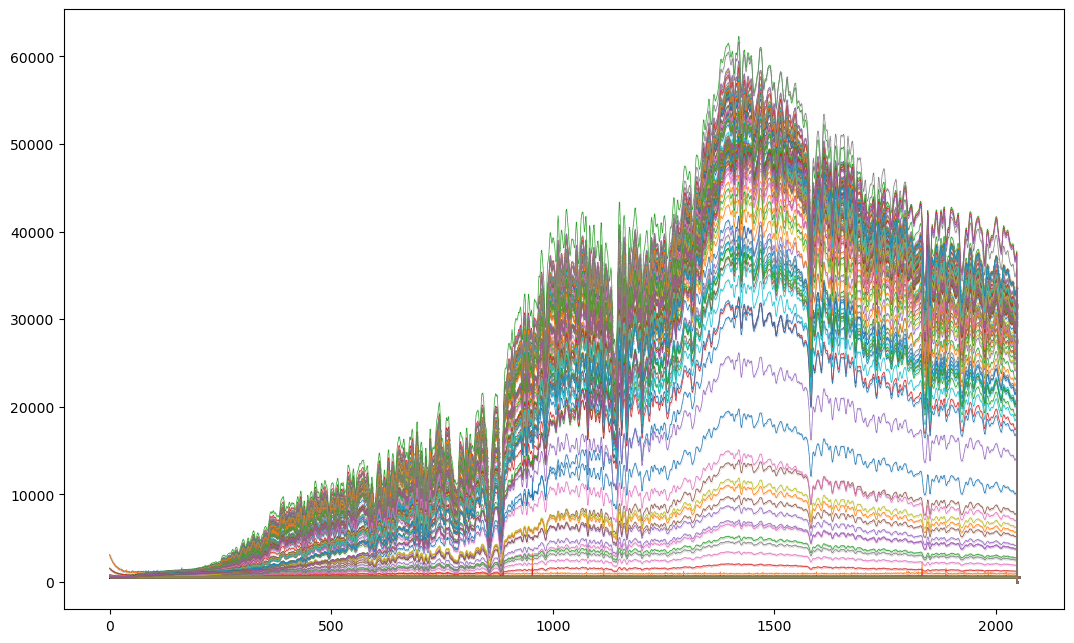

In [28]:
ax = plt.figure(figsize=(10,6)).add_axes([0,0,1,1])

# plot only SQ routines, say the first one, whole data array 
ind = L0data_df['routine_code'] == 'SQ'

for i in np.arange(0,225):
    ax.plot(L0data_df['data'][ind][i], '.-',ms=.1,lw=.5)

In [ ]:
reload(dl0)
# Setup parameters
start_date = '20240701'
#end_date = '20240703'
end_date = '20241231'

url = 'https://data.pandonia-global-network.org/Rome-SAP/Pandora117s1/L0/'

columns_to_read = ['time', 'routine_code', 'integration_time','routine_count','repetition_count',
                   'filterwheel_pos1','filterwheel_pos2',
                   'aux_spec_temp',
                   'head_sens_temp',
                   'elec_temp1'
                   ]
allL0data_df = pd.DataFrame()

# Loop over the dates between start_date and end_date
for date in pd.date_range(start=start_date, end=end_date):
    date_str = date.strftime('%Y%m%d')
    
    try:
        # Construct the file URL
        link = f'Pandora117s1_Rome-SAP_{date_str}_L0.txt.bz2'
        file_url = url + link
        
        # Read the L0 file for this date
        L0data_df, skipped_df = dl0.read_L0file(file_url, columns_to_read)
        
        # Filter only the SQ routines
        ind = L0data_df['routine_code'] == 'SQ'
        L0data_df = L0data_df[ind]

        # Add a date column to identify the source date
        L0data_df['date'] = date_str
        
        # Append to the main dataframe
        if L0data_df is not None and not L0data_df.empty:
            allL0data_df = pd.concat([allL0data_df, L0data_df], ignore_index=False)
            print(f"Successfully processed data for {date_str} ({allL0data_df['date'].nunique()} of {len(pd.date_range(start=start_date, end=end_date))})")
        else:
            print(f"No data found for {date_str}")
            
    except Exception as e:
        print(f"Error processing data for {date_str}: {str(e)}")
        continue

allL0data_df.head()

In [ ]:
def load_L0_data(location, panID, start_date, end_date, columns_to_read, existing_df=None):
    """
    Load L0 data for date range, optionally appending to existing dataframe.
    
    Args:
        start_date (datetime): Start date
        end_date (datetime): End date  
        columns_to_read (list): Columns to extract from files
        existing_df (pd.DataFrame, optional): Existing dataframe to append to
   
    Returns:
        pd.DataFrame: Combined L0 data
    """

    #location = 'Rome-SAP'
    #panID = '117'
    spec = 's1'

    #url = 'https://data.pandonia-global-network.org/Rome-SAP/Pandora117s1/L0/'
    url = f'https://data.pandonia-global-network.org/{location}/Pandora{panID}{spec}/L0/'

    allL0data_df = pd.DataFrame() if existing_df is None else existing_df.copy()
    
    # Get existing dates to avoid reloading
    existing_dates = set(allL0data_df['date'].unique()) if not allL0data_df.empty else set()
    
    k=0
    for date in pd.date_range(start=start_date, end=end_date):
        date_str = date.strftime('%Y%m%d')
        
        # Skip if date already exists in dataframe
        if date_str in existing_dates:
            print(f"Data for {date_str} already loaded")
            continue
            
        try:
            #link = f'Pandora117s1_Rome-SAP_{date_str}_L0.txt.bz2'
            link = f'Pandora{panID}{spec}_{location}_{date_str}_L0.txt.bz2'
            file_url = url + link
            
            L0data_df, skipped_df = dl0.read_L0file(file_url, columns_to_read)
            
            # Filter SQ routines
            ind = L0data_df['routine_code'] == 'SQ'
            L0data_df = L0data_df[ind]
            L0data_df['date'] = date_str
            
            if not L0data_df.empty:
                allL0data_df = pd.concat([allL0data_df, L0data_df], ignore_index=False)
                print(f"Added data for {date_str} ({k} of {len(pd.date_range(start=start_date, end=end_date))})")
            else:
                print(f"No data found for {date_str}")
                
        except Exception as e:
            print(f"Error processing {date_str}: {str(e)}")
            continue
        k+=1
            
    # Sort by date and time before returning
    allL0data_df = allL0data_df.sort_values(['date', 'time'])

    return allL0data_df

In [ ]:
allL0data_df.iloc[0].date,allL0data_df.iloc[-1].date

In [ ]:
start_date = '20240101'
end_date = '20241231'

location = 'Rome-SAP'
panID = '117'

allL0data_df3 = load_L0_data(location,panID,start_date, end_date, columns_to_read, allL0data_df2)

In [ ]:
allL0data_df3.iloc[0].date,allL0data_df3.iloc[-1].date

In [ ]:
allL0data_df3.sort_index().head()

In [ ]:
# save as pkl file (not parquet yet) in /data/l0_datasets
#save only SQ routines

ind = allL0data_df3['routine_code'] == 'SQ'
allL0data_df_rout = allL0data_df3[ind]
allL0data_df_rout.to_pickle(f'../data/l0_datasets/Pandora117s1_Rome-SAP_{start_date}_{end_date}.pkl')

In [ ]:
allL0data_df3.to_parquet(f'../data/l0_datasets/Pandora117s1_Rome-SAP_{start_date}_{end_date}.parquet')

In [ ]:
start_date = '20240101'
end_date = '20241231'

location = 'Bremen'
panID = '21'

allL0data_df = pd.DataFrame()
allL0data_df = load_L0_data(location,panID,start_date, end_date, columns_to_read, allL0data_df)

In [ ]:
ind = allL0data_df['routine_code'] == 'SQ'
allL0data_df_rout = allL0data_df[ind]
allL0data_df_rout.to_pickle(f'../data/l0_datasets/Pandora{panID}s1_{location}_{start_date}_{end_date}.pkl')